## TAREA 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
#partimos importando los datos para su revisión:
df = pd.read_csv("us_stocks_indicators.csv")

#visualizamos las primeras filas
df.head()

,Year,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,Class,Price Var
0,2014,3.878567,-0.129934,1.790827,7.800696,-0.176558,9.122478,7.021603,7.492154,2.218515,...,-0.160494,-0.273101,-0.255555,-0.156224,-0.074997,-0.180232,-0.440493,3.0,1,5.339413
1,2014,0.200522,-0.108851,0.143151,0.275383,-0.176558,0.487538,0.290552,0.178611,-0.041877,...,-0.071844,-0.091054,-0.133905,-0.149948,-0.052301,-0.180232,-0.207595,3.0,1,18.603845
2,2014,0.432598,-0.105983,0.346556,0.498363,0.082470,0.500981,0.332736,0.710699,0.287607,...,-0.102809,0.037929,-0.351691,0.084760,-0.097541,-0.302438,-0.691079,3.0,1,22.628763
3,2014,0.528338,-0.085962,0.628055,0.089929,-0.176558,0.032375,-0.089120,0.427129,-0.296992,...,-0.081957,0.019561,-0.076142,-0.056113,-0.087647,-0.180232,-0.282402,3.0,1,58.666783
4,2014,5.767776,-0.118091,3.321925,9.931729,-0.176558,13.815935,10.011302,7.390123,4.497094,...,-0.143888,-0.322082,-0.483751,-0.268766,-0.090161,-0.180232,-0.360526,3.0,1,8.886701


In [3]:
#resumen general:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11566 entries, 0 to 11565
Columns: 173 entries, Year to Price Var
dtypes: float64(171), int64(2)
memory usage: 15.3 MB


In [4]:
#estadísticas descriptivas:
df.describe()

,Year,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,Class,Price Var
count,11566.000000,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,...,1.156600e+04,11566.000000,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,1.156600e+04,11566.000000,11566.000000,11566.000000
mean,2016.309009,9.829400e-18,5.529037e-18,1.351542e-17,3.563157e-17,1.228675e-17,2.395916e-17,-4.914700e-18,4.054627e-17,-2.457350e-17,...,3.686025e-17,0.000000,-1.167241e-17,3.010254e-17,3.931760e-17,1.965880e-17,-3.194555e-17,5.631766,0.563289,9.399879
std,1.338240,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,...,1.000043e+00,1.000043,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,2.771835,0.496000,48.198639
min,2014.000000,-3.225344e-01,-6.355583e-01,-2.609973e-01,-3.790054e-01,-1.765584e-01,-3.247911e-01,-3.627913e-01,-5.678763e+00,-4.879652e-01,...,-5.419414e-01,-2.203773,-1.822512e+00,-6.880961e-01,-1.882021e-01,-2.785912e+00,-3.155671e+00,0.000000,0.000000,-99.848024
25%,2015.000000,-3.111421e-01,-1.223931e-01,-2.580146e-01,-3.467723e-01,-1.765584e-01,-3.092519e-01,-3.265122e-01,-3.071961e-01,-3.649260e-01,...,-1.423688e-01,-0.162893,-3.392405e-01,-1.506054e-01,-9.455980e-02,-1.802316e-01,-4.309116e-01,4.000000,0.000000,-18.902335
50%,2016.000000,-2.655389e-01,-8.330691e-02,-2.311623e-01,-2.877230e-01,-1.765584e-01,-2.638085e-01,-2.732237e-01,-2.659536e-01,-3.376780e-01,...,-1.099260e-01,-0.162893,-1.963631e-01,-8.662405e-02,-8.764662e-02,-1.802316e-01,-1.917489e-01,6.000000,1.000000,5.570617
75%,2017.000000,-9.935292e-02,-2.321724e-02,-1.108866e-01,-9.418658e-02,-1.387371e-01,-1.068060e-01,-9.063550e-02,-8.986879e-02,-9.550545e-02,...,-3.729911e-02,0.016092,2.504590e-02,-2.915742e-02,-7.239235e-02,-1.471395e-01,1.895664e-01,8.000000,1.000000,31.174714
max,2018.000000,2.034113e+01,4.958172e+01,1.951298e+01,1.571540e+01,2.270073e+01,1.837112e+01,2.017731e+01,1.752254e+01,1.856972e+01,...,3.913576e+01,30.327640,2.020511e+01,3.553907e+01,3.308486e+01,3.093472e+01,1.539068e+01,10.000000,1.000000,844.186017


In [5]:
#revisar valores nulos por columna:
df.isnull().sum().sum()

0

In [6]:
#revisar valores nulos por columna:
df.isna().sum().sum()

0

In [7]:
#distribución de la variable "Year":
df['Year'].value_counts(normalize=True).reset_index()

,Year,proportion
0,2018,0.247017
1,2017,0.234826
2,2016,0.220042
3,2015,0.176379
4,2014,0.121736


# Primera Actividad - Enunciado
 
#### Deberán crear los respectivos conjuntos de datos, específicamente, entrenamiento, validación y prueba. En base a las características del problema y los datos, reflexionen respecto a cómo deberían dividirse los conjuntos, indicando y justificando cuál es la manera correcta de hacerlo. Finalmente, creen los conjuntos de entrenamiento, validación y prueba de acuerdo con el criterio elegido.

#### Entrenen modelos de al menos 4 tipos distintos para resolver el problema de clasificación asociado a los datos. Validen adecuadamente todos los modelos, con el fin de buscar su configuración óptima e indiquen los 2 tipos que mejor rendimiento tienen en el conjunto de prueba. En base a los resultados, comenten en relación con el nivel de sobreajuste observado y la factibilidad de explicar las predicciones de los modelos con mejor rendimiento.

#### División de los conjuntos de datos:

Dado que este DataSet tiene una estructura temporal con datos de 2014 a 2018, es fundamental dividir los datos de manera secuencial para evitar la contaminación de datos futuros en los conjuntos de entrenamiento y validación.

La división será:

Entrenamiento: Datos de 2014 a 2016. Esto asegura que el modelo aprenda solo con datos históricos.

Validación: Datos de 2017. Esto permitirá ajustar los hiperparámetros y validar el rendimiento sin usar datos futuros del conjunto de prueba.

Prueba: Datos de 2018. Este conjunto será usado únicamente para evaluar el rendimiento final.

De esta forma respetaremos la naturaleza temporal de los datos, mientras evitamos data leakage o contaminación de la información. Así mismo simulamos un escenario realista de predicción, independiente en la evaluación y realista en el rendimiento.

In [8]:
#división de conjuntos de entrenamiento, validación y prueba:
train_data = df[df['Year'] <= 2016]
validation_data = df[df['Year'] == 2017]
test_data = df[df['Year'] == 2018]

total_records = len(df)
train_percentage = len(train_data) / total_records * 100
val_percentage = len(validation_data) / total_records * 100
test_percentage = len(test_data) / total_records * 100

percentage_df = pd.DataFrame({
    'Conjunto': ['Entrenamiento (2014-2016)', 'Validacion(2017)', 'Prueba(2018)'],
    '%': [train_percentage, val_percentage, test_percentage]
})

print("Porcentajes por Rango de Tiempo:")

percentage_df

Porcentajes por Rango de Tiempo:


,Conjunto,%
0,Entrenamiento (2014-2016),51.815667
1,Validacion(2017),23.482621
2,Prueba(2018),24.701712


Con respecto a la división de los datos en los 3 conjuntos por criterio temporal, se puede indicar que la división propuesta es la apropiada ya que el conjunto de entrenamiento presenta el 52%, validación 23%, y prueba 25% (aprox). Bajo otras condiciones se podría haber aumentado el tamaño del conjunto de entrenamiento a un 65-70%, ya que podría ayudar a mejorar el rendimiento del modelo, pero no se hubiera podido cumplir con el criterio temporal.

#### Preparación de data para construcción de modelos de clasificación:

In [9]:
#separamos características (X) y variable objetivo (y):
X_train = train_data.drop(columns=['Class'])
y_train = train_data['Class']

X_val = validation_data.drop(columns=['Class'])
y_val = validation_data['Class']

X_test = test_data.drop(columns=['Class'])
y_test = test_data['Class']

print("Distribución de clases en y_train:")
print(y_train.value_counts(normalize=True))

print("Distribución de clases en y_validation:")
print(y_val.value_counts(normalize=True))

print("Distribución de clases en y_test:")
print(y_test.value_counts(normalize=True))

Distribución de clases en y_train:
Class
1    0.61672
0    0.38328
Name: proportion, dtype: float64
Distribución de clases en y_validation:
Class
0    0.705449
1    0.294551
Name: proportion, dtype: float64
Distribución de clases en y_test:
Class
1    0.706685
0    0.293315
Name: proportion, dtype: float64


Lo que podemos observar acá es que en cada uno de los conjuntos de datos hay un desbalance con respecto a la variable que class.
En este sentido, es muy importante que al momento de evaluar los modelos, se considere este desbalance, para lo cual utilizaremos la métrica de rendimiento F1-score, que se calcula como la media armónica entre precisión y recall, lo que lo hace ideal para evaluar modelos en este tipo de situaciones.

#### Entrenamiento y evaluación de modelos:

In [10]:
#configuración de librerías para Modelos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

random_state = 42

#definición de los modelos iniciales:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "Bagging with KNN": BaggingClassifier(estimator=KNeighborsClassifier(), random_state=0),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=0),
    "Neural Network": MLPClassifier(random_state=0)
}

#espacio de configuración de hiperparámetros para cada modelo:
param_grids = {
    "Decision Tree": {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5]},
    "Random Forest": {'n_estimators': [50, 100], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]},
    "Gradient Boosting": {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]},
    "Bagging with KNN": {'n_estimators': [10, 20, 30], 'max_samples': [0.5, 0.8], 'max_features': [0.5, 0.8], 'estimator__n_neighbors': [3, 5, 7, 10]},
    "SVM (RBF Kernel)": {'C': [0.1, 1], 'gamma': ['scale', 'auto']},
    "Neural Network": {'hidden_layer_sizes': [(50, 25), (100, 50), (150, 75)], 'activation': ['relu', 'tanh'], 'learning_rate': ['constant', 'adaptive']}
}

#función para entrenar y buscar la mejor configuración:
def train_and_select_best_model(model_name, model, param_grid, X_train, y_train, X_val, y_val, scoring='f1'):
    try:
        #GridSearchCV para optimizar hiperparámetros:
        grid_search = GridSearchCV(
            estimator=model, param_grid=param_grid, scoring=scoring, cv=3, n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        
        #mejor estimador y resultados:
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        y_pred_val = best_model.predict(X_val)
        accuracy_val = accuracy_score(y_val, y_pred_val)
        f1_val = f1_score(y_val, y_pred_val)
        
        print(f"\nModelo: {model_name}")
        print(f"Mejores parámetros: {best_params}")
        print(f"Accuracy en validación: {accuracy_val:.4f}")
        print(f"F1 Score en validación: {f1_val:.4f}")
        
        return best_model, accuracy_val, f1_val
    except Exception as e:
        warnings.warn(f"El modelo {model_name} falló: {e}")
        return None, 0, 0

#entrenamiento y evaluación en validación:
best_models = {}
validation_scores = []

for model_name, model in models.items():
    print(f"\nEntrenando el modelo: {model_name}")
    param_grid = param_grids[model_name]
    best_model, accuracy_val, f1_val = train_and_select_best_model(model_name, model, param_grid, X_train, y_train, X_val, y_val)
    if best_model:
        best_models[model_name] = best_model
        validation_scores.append((model_name, accuracy_val, f1_val))

#evaluación en el conjunto de prueba:
print("\nEvaluación en el conjunto de prueba:")
test_scores = []

for model_name, best_model in best_models.items():
    y_pred_test = best_model.predict(X_test)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    print(f"{model_name} - Accuracy Test: {accuracy_test:.4f}, F1 Score Test: {f1_test:.4f}")
    test_scores.append((model_name, accuracy_test, f1_test))


Entrenando el modelo: Decision Tree

Modelo: Decision Tree
Mejores parámetros: {'max_depth': 3, 'min_samples_split': 2}
Accuracy en validación: 1.0000
F1 Score en validación: 1.0000

Entrenando el modelo: Random Forest

Modelo: Random Forest
Mejores parámetros: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy en validación: 0.9989
F1 Score en validación: 0.9981

Entrenando el modelo: Gradient Boosting

Modelo: Gradient Boosting
Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Accuracy en validación: 1.0000
F1 Score en validación: 1.0000

Entrenando el modelo: Bagging with KNN

Modelo: Bagging with KNN
Mejores parámetros: {'estimator__n_neighbors': 10, 'max_features': 0.8, 'max_samples': 0.5, 'n_estimators': 30}
Accuracy en validación: 0.9930
F1 Score en validación: 0.9882

Entrenando el modelo: SVM (RBF Kernel)

Modelo: SVM (RBF Kernel)
Mejores parámetros: {'C': 1, 'gamma': 'auto'}
Accuracy en validación: 0.9691
F1 Score en validaci

# Primera Actividad - Análisis de resultados

Validación de datos: La elección de los mejores parámetros permitió maximizar métricas como Accuracy y F1 Score. Es notable que modelos como Decision Tree y Gradient Boosting lograron métricas perfectas en el conjunto de validación, lo que puede indicar presencia de sobreajuste. Los demás modelos, no tienen malos resultados, al contrario están todos cercanos a un rendimiento casi perfecto. No obstante, para determinar si hay presencia de sobreajuste, debemos observar los resultados en el conjunto de prueba (test), que evalúa cómo el modelo generaliza en datos completamente nuevos y cronológicamente posteriores.

En el conjunto de prueba, los dos modelos con mejor puntaje son el Decision Tree y el Gradient Boosting, ambos alcanzando métricas perfectas (Accuracy y F1 Score = 1.00). En validación, estos modelos también lograron valores ideales, lo que podría haber sugerido sobreajuste; sin embargo, la consistencia de los resultados en el conjunto de prueba confirma su capacidad de generalización. En términos de explicabilidad, Decision Tree es completamente interpretable gracias a sus reglas claras y visualización directa, mientras que Gradient Boosting, aunque más complejo, combina robustez y buen rendimiento en problemas no lineales, sacrificando algo de interpretabilidad en favor de precisión.

Adicionalmente, podemos mencionar que los otros modelos también tienen un rendimiento casi perfecto (98-99%), lo que nos indica que si bien el Decision Tree y el Gradient Boosting son los dos mejores modelos según su rendimiento en todos los conjuntos, otras opciones como Random Forest, Bagging with KNN, SVM-RBF y Neural Network también son modelos sólidos para predecir la variable class.

# Segunda Actividad - Enunciado

#### Realicen un proceso de clustering sobre los ejemplos de entrenamiento, con el fin de segmentarlos en grupos. Comparen los resultados de este proceso al incluir una etapa de reducción de dimensionalidad previa al clustering.

#### Finalmente, con fines de análisis, discreticen la variable Price Var, por ejemplo, en deciles o quintiles, y comente con respecto a la composición de los clústeres encontrados en relación con esta variable. Utilicen visualizaciones para facilitar su análisis.

In [11]:
#configuración de librerías
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap

In [12]:
#además de quitar la variable class (etiqueta), quitamos el año del conjunto de entrenamiento:
X_train_v2 = train_data.drop(columns=['Class', 'Year'])

#por las características del conjunto de datos, aplicamos una estandarización, dejando la media en 0 y la desviación estándar en 1:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_v2)

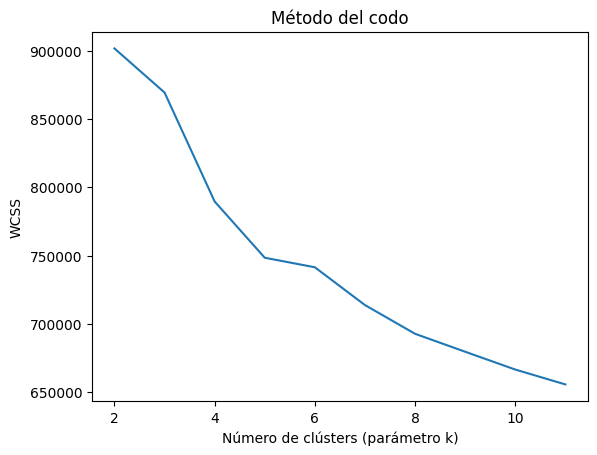

In [13]:
#rango de valores de K para probar en el clustering:
k_range = 12

#lista para almacenar los valores de WCSS para cada valor de K:
wcss = []

#entrenamos el modelo de KMeans con diferentes valores de K:
for i in range(2, k_range):  # empezamos desde 2 para evitar k=1
    clasificador = KMeans(n_clusters=i, random_state=random_state).fit(X_train_scaled)
    wcss.append(clasificador.inertia_)

#graficamos la "suma de las distancias dentro del clúster" (WCSS):
plt.plot(range(2, k_range), wcss)
plt.title("Método del codo")
plt.xlabel("Número de clústers (parámetro k)")
plt.ylabel("WCSS")
plt.show()

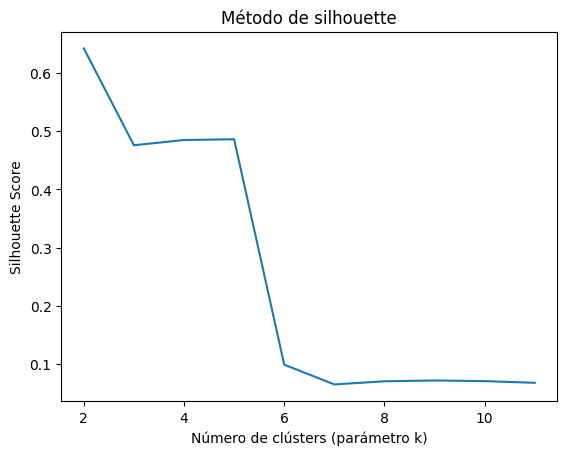

In [14]:
#rango de valores K para probar en el clustering:
k_range = 12

#lista para almacenar los valores de Silhouette para cada valor de K:
silhouettes = []

for i in range(2, k_range):
    clasificador = KMeans(n_clusters = i, random_state = random_state).fit(X_train_scaled)
    s_score = silhouette_score(X_train_scaled, clasificador.predict(X_train_scaled))
    silhouettes.append(s_score)

plt.plot(range(2, k_range), silhouettes)
plt.title("Método de silhouette")
plt.xlabel("Número de clústers (parámetro k)")
plt.ylabel("Silhouette Score")
plt.show()

De los dos métodos anteriores se obtiene el mismo número de clústers (k) óptimo = 5

#### PCA:

In [15]:
#aplicamos KMeans con el número óptimo de clusters:
kmeans = KMeans(n_clusters=5, random_state=random_state).fit(X_train_scaled)
# Obtener las etiquetas de los clusters
labels = kmeans.labels_

# Agregar las etiquetas a los datos para hacer un seguimiento de los clusters
X_train['Cluster'] = labels

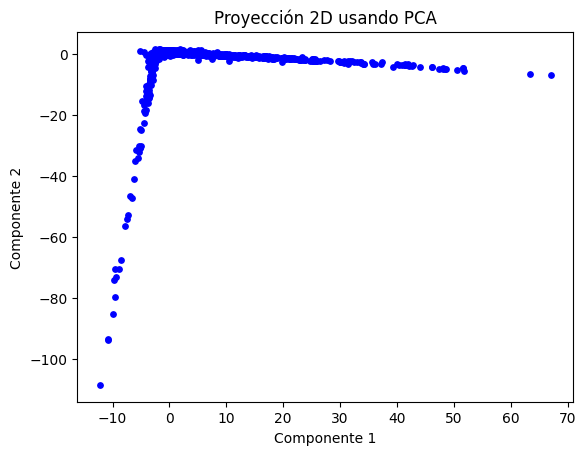

In [16]:
#reducción de dimensionalidad con PCA (2 dimensiones):
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

#graficamos las primeras dos componentes principales para ver cómo se distribuyen:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], s=15, c='blue')
plt.title("Proyección 2D usando PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

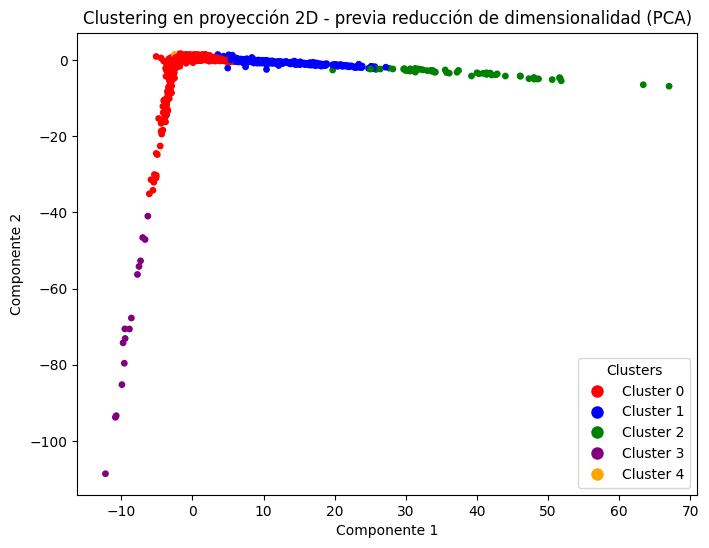

In [17]:
#asignamos colores cada clúster:
cluster_colors = ['red', 'blue', 'green', 'purple', 'orange']
cmap = ListedColormap(cluster_colors)

#graficamos puntos con colores según el clúster:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                       s=15, c=labels, cmap=cmap)

#leyenda:
legend_labels = [f"Cluster {i-1+1}" for i in range(len(cluster_colors))]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in cluster_colors]
plt.legend(handles, legend_labels, title="Clusters", loc="best")

plt.title("Clustering en proyección 2D - previa reducción de dimensionalidad (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

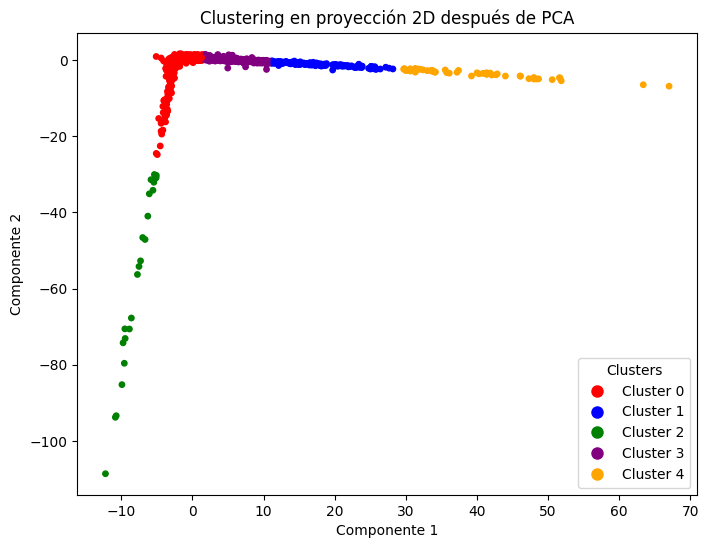

Silhouette Score sin PCA: 0.4862
Silhouette Score con PCA: 0.7231


In [18]:
#KMeans sobre los datos con reducción de dimensionalidad con PCA:
kmeans_pca = KMeans(n_clusters=5, random_state=42).fit(X_train_pca)
labels_pca = kmeans_pca.labels_

#agregamos etiquetas de clústeres a los datos:
X_train['Cluster_pca'] = labels_pca

#graficamos los resultados del clustering:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                       c=labels_pca, cmap=cmap, s=15)

#leyenda:
legend_labels = [f"Cluster {i-1+1}" for i in range(len(cluster_colors))]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in cluster_colors]
plt.legend(handles, legend_labels, title="Clusters", loc="best")

plt.title("Clustering en proyección 2D después de PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

#evaluamos la calidad del clustering con Silhouette Score:
silhouette_no_pca = silhouette_score(X_train_scaled, labels)
silhouette_with_pca = silhouette_score(X_train_pca, labels_pca)

print(f"Silhouette Score sin PCA: {silhouette_no_pca:.4f}")
print(f"Silhouette Score con PCA: {silhouette_with_pca:.4f}")

Tanto al observar la visualización como los valores de Silhouette Score resultantes, se tiene que mejora significativamente al aplicar PCA (de 0.4862 a 0.7231), lo que indica que la reducción de dimensionalidad ayudó a mejorar la cohesión dentro de los clústeres y la separación entre ellos.

#### t-SNE:

In [19]:
#reducción de dimensionalidad con t-SNE (2 dimensiones):
tsne = TSNE(n_components=2, random_state=random_state)
X_train_tsne = tsne.fit_transform(X_train_scaled)

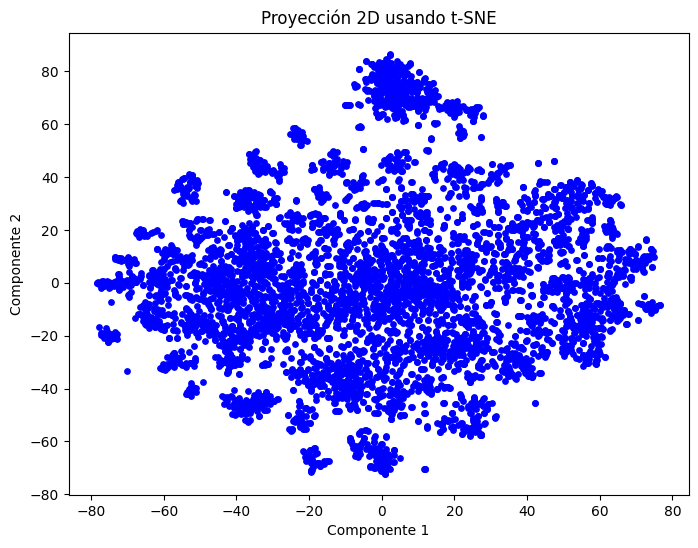

In [20]:
#graficamos las dos componentes para ver cómo se distribuyen:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c='blue')
plt.title("Proyección 2D usando t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

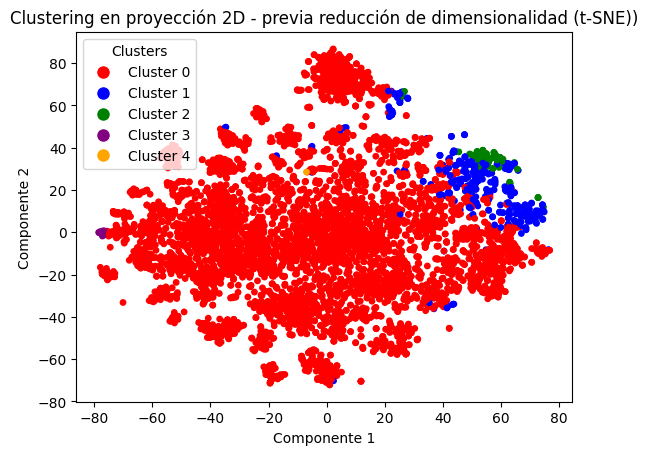

In [21]:
#graficamos los puntos con colores por clúster:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c=labels, cmap=cmap)

#leyenda:
legend_labels = [f"Cluster {i-1+1}" for i in range(len(cluster_colors))]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in cluster_colors]
plt.legend(handles, legend_labels, title="Clusters", loc="best")

plt.title("Clustering en proyección 2D - previa reducción de dimensionalidad (t-SNE))")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

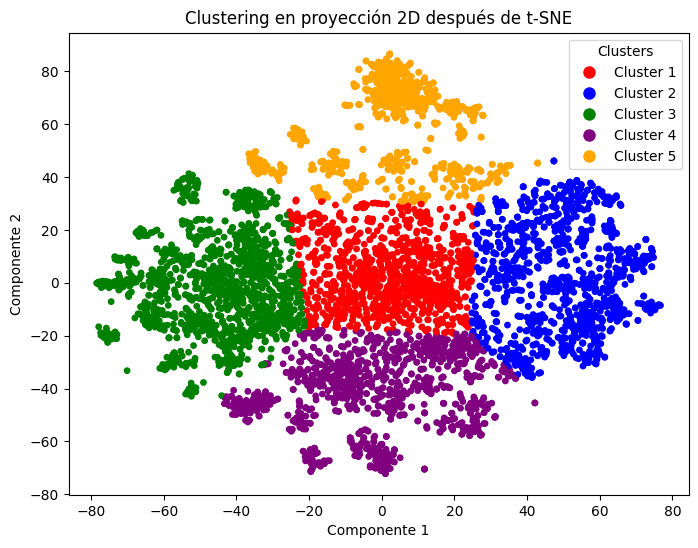

Silhouette Score sin t-SNE: 0.4862
Silhouette Score con t-SNE: 0.3997


In [22]:
#KMeans sobre los datos con reducción de dimensionalidad con t-SNE:
kmeans_tsne = KMeans(n_clusters=5, random_state=random_state).fit(X_train_tsne)

#agregamos etiquetas a los datos para hacer un seguimiento de los clusters:
labels_tsne = kmeans_tsne.labels_

X_train['Cluster_tsne'] = labels_tsne

#graficamos los resultados del clustering con t-SNE:
plt.figure(figsize=(8, 6))

#graficamos los puntos con colores por clúster:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c=labels_tsne, cmap=cmap)

#leyenda:
legend_labels = [f"Cluster {i+1}" for i in range(len(cluster_colors))]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in cluster_colors]
plt.legend(handles, legend_labels, title="Clusters", loc="best")

plt.title("Clustering en proyección 2D después de t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

#evaluamos la calidad del clustering con Silhouette Score:
silhouette_no_tsne = silhouette_score(X_train_scaled, labels)
silhouette_with_tsne = silhouette_score(X_train_tsne, labels_tsne)

print(f"Silhouette Score sin t-SNE: {silhouette_no_tsne:.4f}")
print(f"Silhouette Score con t-SNE: {silhouette_with_tsne:.4f}")

Si bien la visualización mejora notablemente con respecto al clustering previo a reducción con dimensionalidad con t-SNE, en este caso al observar los valores del Silhouette Score, este disminuye al aplicar t-SNE (de 0.4862 sin t-SNE a 0.3997 con t-SNE), lo que indica que la reducción de dimensionalidad con t-SNE no benefició al clustering.

#### Discretización de Price Var

In [23]:
#discretizamos la variable Price Var en deciles:
X_train['Price Var Deciles'] = pd.qcut(X_train['Price Var'], 10, labels=False)

#analizamos cómo se distribuyen los distintos clústeres (según clustering) con respecto a los deciles de Price Var:
cluster_analysis = X_train.groupby(['Cluster', 'Price Var Deciles']).size().unstack(fill_value=0)
cluster_pca_analysis = X_train.groupby(['Cluster_pca', 'Price Var Deciles']).size().unstack(fill_value=0)
cluster_tsne_analysis = X_train.groupby(['Cluster_tsne', 'Price Var Deciles']).size().unstack(fill_value=0)

print(cluster_analysis)
print(cluster_pca_analysis)
print(cluster_tsne_analysis)

Price Var Deciles    0    1    2    3    4    5    6    7    8    9
Cluster                                                            
0                  580  565  559  551  538  519  534  536  566  580
1                   15   26   33   35   47   70   58   58   29   13
2                    0    5    6   10   15   10    6    5    4    3
3                    5    3    1    3    0    0    1    0    0    3
4                    0    0    0    0    0    0    0    0    0    1
Price Var Deciles    0    1    2    3    4    5    6    7    8    9
Cluster_pca                                                        
0                  563  540  520  503  481  471  477  490  538  559
1                    4   15   17   11   25   28   21   28   14    5
2                    9    6    1    3    0    0    1    0    0    4
3                   24   35   55   72   82   91   95   79   44   30
4                    0    3    6   10   12    9    5    2    3    2
Price Var Deciles    0    1    2    3    4    5 

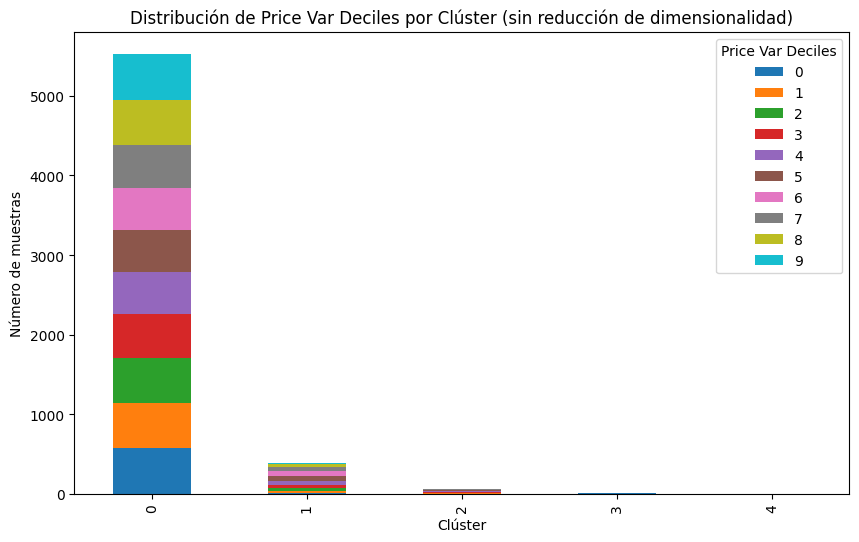

In [24]:
#graficamos la distribución de los deciles de Price Var en cada cluster sin ningún tipo de reducción de dimensionalidad:
cluster_analysis.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribución de Price Var Deciles por Clúster (sin reducción de dimensionalidad)")
plt.xlabel("Clúster")
plt.ylabel("Número de muestras")
plt.show()

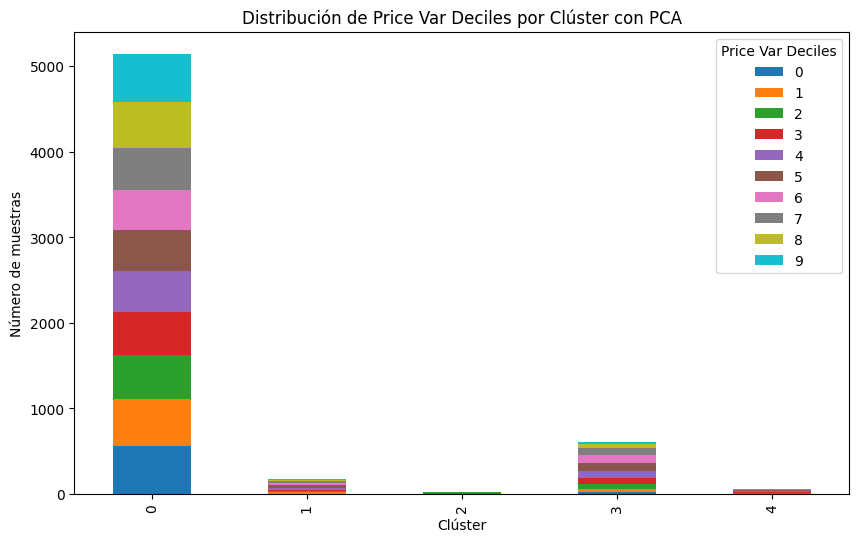

In [25]:
#graficamos la distribución de los deciles de Price Var en cada cluster:
cluster_pca_analysis.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribución de Price Var Deciles por Clúster con PCA")
plt.xlabel("Clúster")
plt.ylabel("Número de muestras")
plt.show()

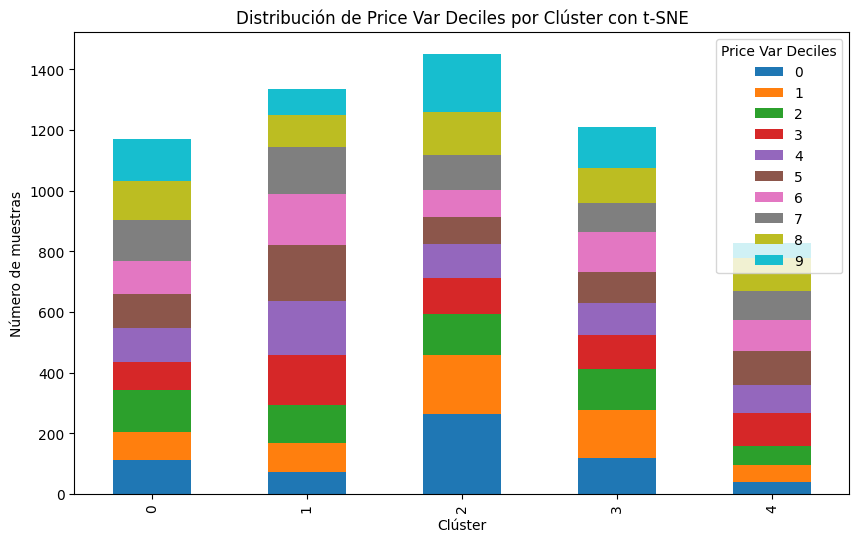

In [26]:
#graficamos la distribución de los deciles de Price Var en cada cluster:
cluster_tsne_analysis.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribución de Price Var Deciles por Clúster con t-SNE")
plt.xlabel("Clúster")
plt.ylabel("Número de muestras")
plt.show()

Se puede observar que en ningún tipo de clustering se logra una distinción muy marcada con respecto a los deciles de la variable Price Var. Esto se explica, porque previo a realizar cualquier método de clustering, se llevó a cabo una estandarización de las variables del conjunto de datos. Lo que implica que se equilibra el peso de todas las variables al momento de generar los clusters. 
Esto fue necesario, puesto a que de no ser así, las variables con mayor escala, serían las que dominarían la formación de cada grupo. En este sentido, si no hubieramos estanzarizado las variables, al ser Price Var la variable que presentaba mayor escala entre todas las demás, los clusters creados hubieran resultado en grupos que hubieran discriminado por deciles (como mostramos a continuación).

## *Clustering sin estandarización del conjunto de datos*

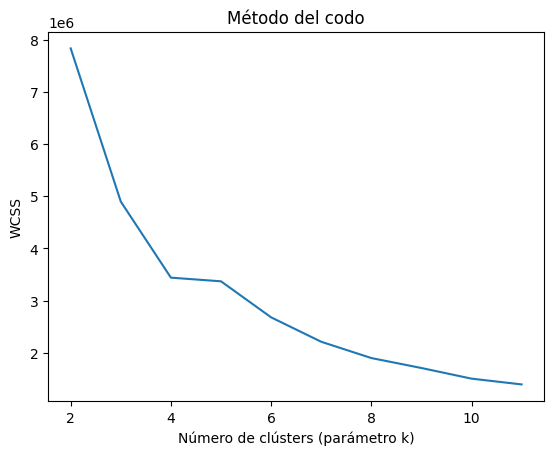

In [27]:
#rango de valores de K para probar en el clustering:
k_range = 12

#lista para almacenar los valores de WCSS para cada valor de K:
wcss = []

#entrenamos el modelo de KMeans con diferentes valores de K:
for i in range(2, k_range):  # empezamos desde 2 para evitar k=1
    clasificador = KMeans(n_clusters=i, random_state=random_state).fit(X_train_v2)
    wcss.append(clasificador.inertia_)

#graficamos la "suma de las distancias dentro del clúster" (WCSS):
plt.plot(range(2, k_range), wcss)
plt.title("Método del codo")
plt.xlabel("Número de clústers (parámetro k)")
plt.ylabel("WCSS")
plt.show()

k óptimo = 4

In [28]:
#aplicamos KMeans con el número óptimo de clusters:
kmeans = KMeans(n_clusters=4, random_state=random_state).fit(X_train_v2)
# Obtener las etiquetas de los clusters
labels = kmeans.labels_

# Agregar las etiquetas a los datos para hacer un seguimiento de los clusters
X_train['Cluster'] = labels

In [29]:
#reducción de dimensionalidad con PCA (2 dimensiones):
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_v2)

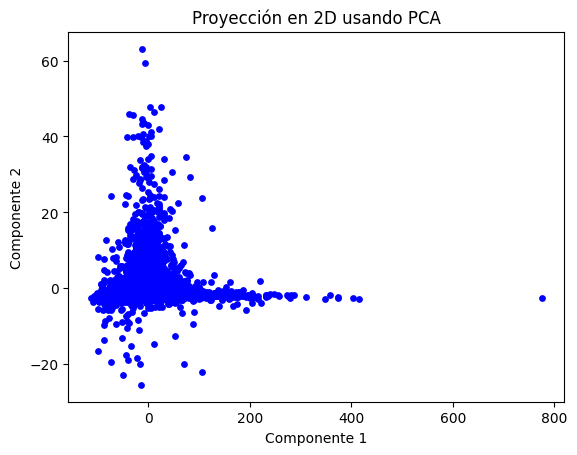

In [30]:
#graficamos las primeras dos componentes principales para ver cómo se distribuyen:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], s=15, c='blue')
plt.title("Proyección en 2D usando PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

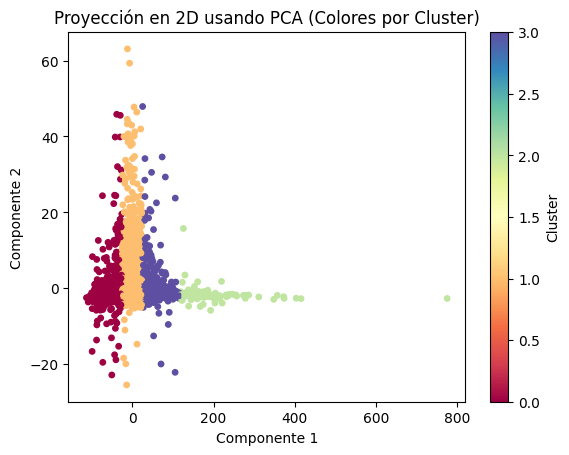

In [31]:
#graficamos las primeras dos componentes principales, coloreadas según los clusters:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], s=15, c=labels, cmap='Spectral')
plt.title("Proyección en 2D usando PCA (Colores por Cluster)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label='Cluster')
plt.show()

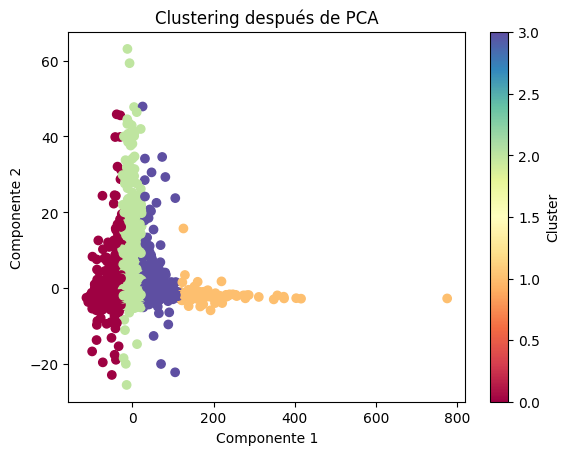

Silhouette Score sin PCA: -0.0467
Silhouette Score con PCA: 0.5055


In [32]:
#KMeans sobre los datos con reducción de dimensionalidad con PCA:
kmeans_pca = KMeans(n_clusters=4, random_state=random_state).fit(X_train_pca)
# Obtener las etiquetas de los clusters
labels_pca = kmeans_pca.labels_

#agregamos etiquetas a los datos para hacer un seguimiento de los clusters:
X_train['Cluster_pca'] = labels_pca

#graficamos los resultados del clustering con PCA:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=labels_pca, cmap='Spectral')
plt.title("Clustering después de PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label='Cluster')
plt.show()

#evaluamos la calidad del clustering con Silhouette Score:
silhouette_no_pca = silhouette_score(X_train_scaled, labels)
silhouette_with_pca = silhouette_score(X_train_pca, labels_pca)

print(f"Silhouette Score sin PCA: {silhouette_no_pca:.4f}")
print(f"Silhouette Score con PCA: {silhouette_with_pca:.4f}")

In [33]:
#reducción de dimensionalidad con t-SNE (2 dimensiones):
tsne = TSNE(n_components=2, random_state=random_state)
X_train_tsne = tsne.fit_transform(X_train_v2)

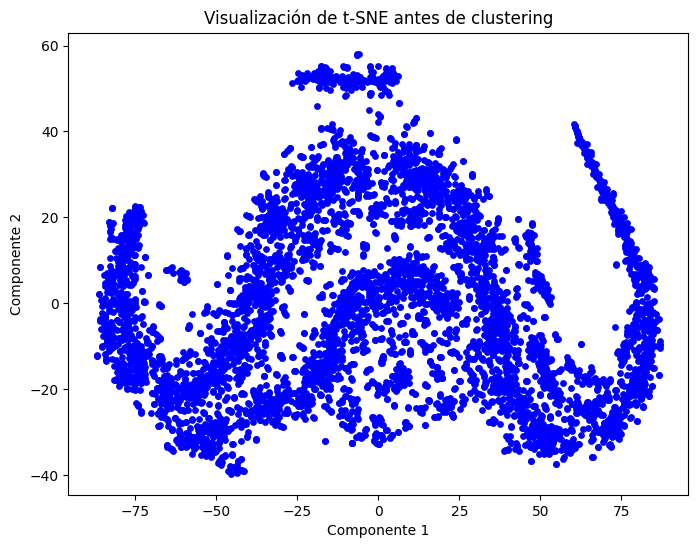

In [34]:
#graficamos las dos componentes para ver cómo se distribuyen:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c='blue')
plt.title("Visualización de t-SNE antes de clustering")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

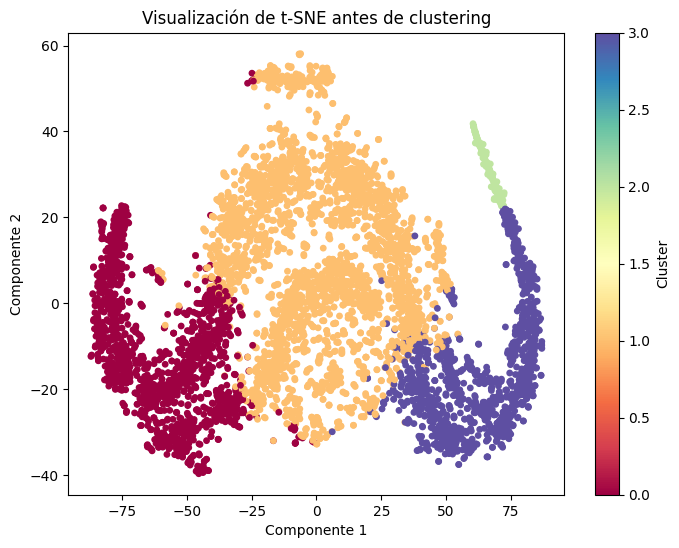

In [35]:
#graficamos las dos componentes, coloreadas según los clusters:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c=labels, cmap='Spectral')
plt.title("Visualización de t-SNE antes de clustering")
#graficamos las primeras dos componentes principales, coloreadas según los clusters
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label='Cluster')
plt.show()

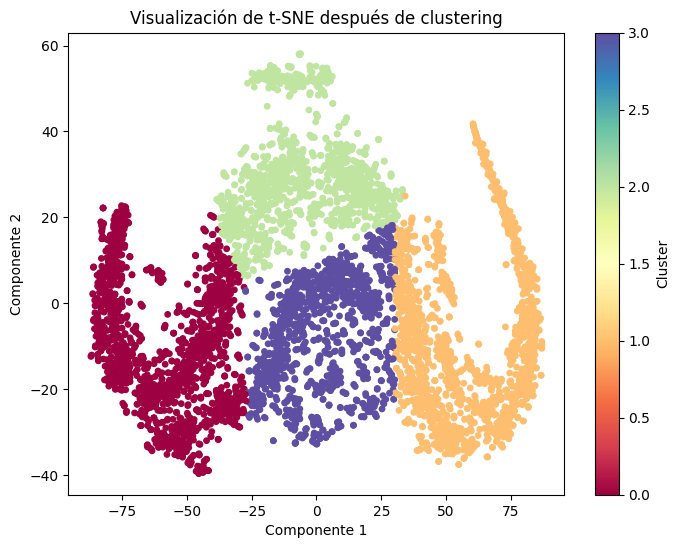

Silhouette Score sin PCA: -0.0467
Silhouette Score con t-SNE: 0.4221


In [36]:
#KMeans sobre los datos con reducción de dimensionalidad con t-SNE:
kmeans_tsne = KMeans(n_clusters=4, random_state=random_state).fit(X_train_tsne)

#agregamos etiquetas a los datos para hacer un seguimiento de los clusters:
labels_tsne = kmeans_tsne.labels_

X_train['Cluster_tsne'] = labels_tsne

#graficamos los resultados del clustering con t-SNE:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], s=15, c=labels_tsne, cmap='Spectral')
plt.title("Visualización de t-SNE después de clustering")
# Graficamos las primeras dos componentes principales, coloreadas según los clusters
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label='Cluster')
plt.show()

#evaluamos la calidad del clustering con Silhouette Score:
silhouette_no_tsne = silhouette_score(X_train_scaled, labels)
silhouette_with_tsne = silhouette_score(X_train_tsne, labels_tsne)

print(f"Silhouette Score sin PCA: {silhouette_no_pca:.4f}")
print(f"Silhouette Score con t-SNE: {silhouette_with_tsne:.4f}")

In [37]:
# Discretizamos la variable Price Var en deciles
X_train['Price Var Deciles'] = pd.qcut(X_train['Price Var'], 10, labels=False)

# Analizamos cómo se distribuyen los clústeres con respecto a los deciles de Price Var
cluster_analysis = X_train.groupby(['Cluster', 'Price Var Deciles']).size().unstack(fill_value=0)
cluster_pca_analysis = X_train.groupby(['Cluster_pca', 'Price Var Deciles']).size().unstack(fill_value=0)
cluster_tsne_analysis = X_train.groupby(['Cluster_tsne', 'Price Var Deciles']).size().unstack(fill_value=0)

print(cluster_analysis)
print(cluster_pca_analysis)
print(cluster_tsne_analysis)

Price Var Deciles    0    1    2    3    4    5    6    7    8    9
Cluster                                                            
0                  600  599  333    0    0    0    0    0    0    0
1                    0    0  266  599  600  599  599  462    0    0
2                    0    0    0    0    0    0    0    0    0  128
3                    0    0    0    0    0    0    0  137  599  472
Price Var Deciles    0    1    2    3    4    5    6    7    8    9
Cluster_pca                                                        
0                  600  599  364    0    0    0    0    0    0    0
1                    0    0    0    0    0    0    0    0    0  128
2                    0    0  235  599  600  599  599  480    0    0
3                    0    0    0    0    0    0    0  119  599  472
Price Var Deciles    0    1    2    3    4    5    6    7    8    9
Cluster_tsne                                                       
0                  600  593  439   12    1    0 

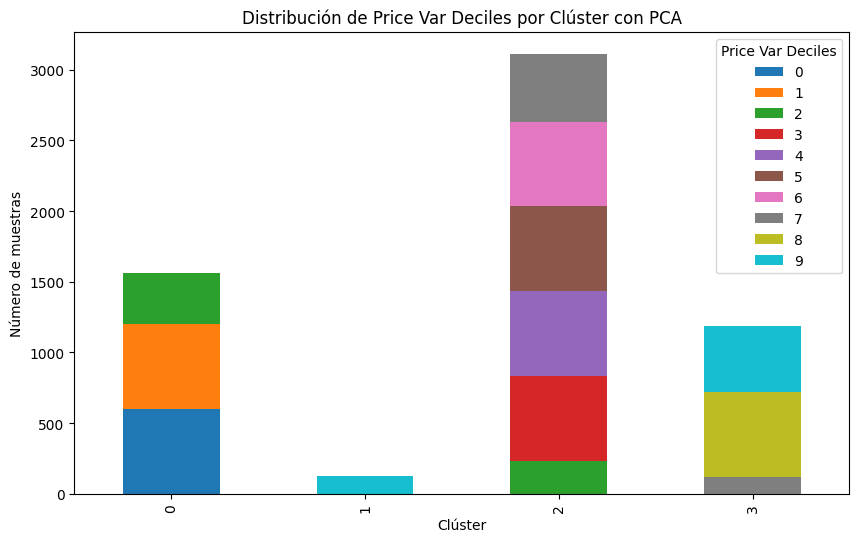

In [38]:
#graficamos la distribución de los deciles de Price Var en cada cluster:
cluster_pca_analysis.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribución de Price Var Deciles por Clúster con PCA")
plt.xlabel("Clúster")
plt.ylabel("Número de muestras")
plt.show()

Si consideramos que el clustering con mejor rendimiento es el que se aplica luego de la reducción de dimensionalidad por PCA (Silhouette Score = 0.5055), obtenemos que los clusters que agrupan las acciones con mayor variabilidad de precio son el 1 y 3. Siendo el 0 el que agrupa las acciones con menor variabilidad. Por último el cluster 2 es aquel que contiene a las variables con deciles intermedios de Price Var, lo que nos indica que podemos categorizar los clusters de la siguiente manera:

- Cluster 0: baja variabilidad (acciones para inversores aversos al riesgo)
- Cluster 2: variabilidad media (acciones para inversores que no son ni aversos ni amantes al riesgo)
- Cluster 3 y 1: alta variabilidad (acciones para inversores amantes al riesgo)

Es importante mencionar que esta clusterización se logra gracias a que no se estandarizaron los datos del conjunto, lo que implica que hay un alto sesgo al momento de formar los grupos de acciones debido al peso que toma la variable Price Var por la escala alta que presenta.